# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *Darren Sluss & Matt Hunter*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [ ]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>


In [2]:
# Your imports here
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [3]:
# Load train.csv here

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


*Your written answers for Part A:*

- Image size chosen and why: **N/A | Told not to answer and start with part B**
- Stratification decision and why: **N/A | Told not to answer and start with part B**


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [4]:
# Build your CNN model here

model = Sequential()

model.add(Conv2D(32, kernel_size= 3, activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size= 2, strides = 2))

model.add(Conv2D(64, kernel_size= 3, activation='relu'))
model.add(MaxPooling2D(pool_size= 2, strides = 2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Compile your model here

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

*Your architecture justification (one paragraph):*

For our CNN model, we used two Conv2D/MaxPooling2D blocks with 3 by 3 Kernel sizes becuase it is a good fit for capturing local patterns. We also used a 2 by 2 pooling size because of the 28x28 images to not shrink the images too much. The number of filters in the first layer is 32 followed by 64 in the second layer. This is standard practice to add more filters as we get to deeper layers. Early layers are looking for edges while the deeper layers are making shapes which is why we add more filters on the deeper layers. After we flatten, we use dense 128 layer to narrow features down before the output layer. Dense 10 is the output layer and we use softmax for each of the 10 classes to get a probability that adds up to 1.





---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [6]:
# Train your model here (save the result as `history`)

history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64
)

Epoch 1/15
 34/750 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.3576 - loss: 1.8355

KeyboardInterrupt: 

In [7]:
# Plot training vs. validation loss and accuracy here
import matplotlib.pyplot as plt
def plot_history(history, title, show_accuracy=True):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()

plot_history(history, "Part 1 -- Regression: Training vs. Validation Loss")



NameError: name 'history' is not defined

*Your fit diagnosis, with specific evidence from your curve:*
Our baseline model shows that it overfit. The validation loss bottomed out around epoch 9 and then rose while training loss kept falling.



In [8]:
# Evaluate on the test set and report accuracy here

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7195 - loss: 0.7980
Test accuracy: 71.95%
Test Loss: 0.7980


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*
 We're applying Early Stopping to halt training once validation loss stops improving.



In [9]:


# Build your improved model here

from tensorflow.keras.callbacks import EarlyStopping

improved_model = Sequential([
    Conv2D(32, kernel_size=3, activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=2, strides=2),
    Conv2D(64, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
improved_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
# Train your improved model here

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

improved_history = improved_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)



Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.9443 - loss: 0.1503 - val_accuracy: 0.9144 - val_loss: 0.2442
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.9499 - loss: 0.1355 - val_accuracy: 0.9081 - val_loss: 0.2796
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.9547 - loss: 0.1222 - val_accuracy: 0.9163 - val_loss: 0.2519
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 86s 63ms/step - accuracy: 0.9590 - loss: 0.1084 - val_accuracy: 0.9134 - val_loss: 0.2820
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.9645 - loss: 0.0967 - val_accuracy: 0.9149 - val_loss: 0.2789
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.9680 - loss: 0.0870 - val_accuracy: 0.9153 - val_loss: 0.2859


---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | 90.62| 91.11 |
| Fit pattern (good/over/under) |over | good|
| What changed | | added early stopping|

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9111 - loss: 0.2590
Improved model test accuracy: 91.11%


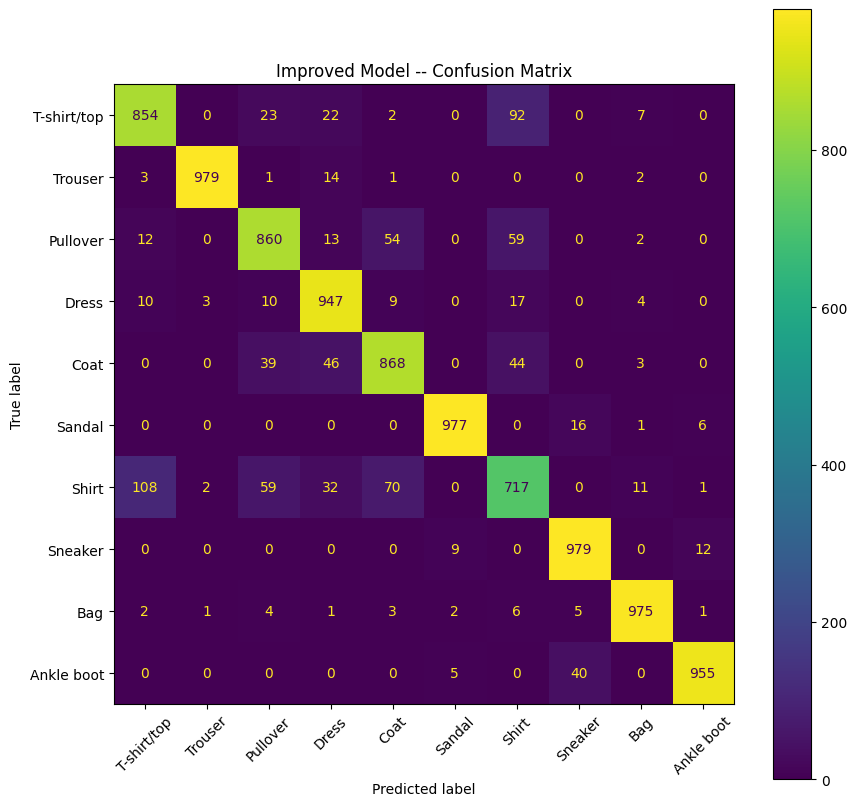

In [16]:

# Evaluate your improved model and build a confusion matrix here
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

y_pred_probs = improved_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

test_loss_improved, test_acc_improved = improved_model.evaluate(x_test, y_test)
print(f"Improved model test accuracy: {test_acc_improved*100:.2f}%")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Improved Model -- Confusion Matrix")
plt.show()

*Your discussion of the confusion matrix:*




---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

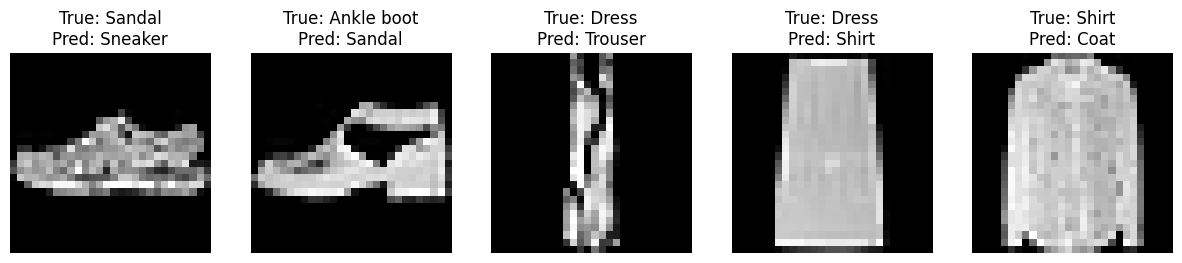

In [17]:
# Find and display misclassified images here

wrong_idx = np.where(y_pred != y_true)[0][:5]

fig, axes = plt.subplots(1, len(wrong_idx), figsize=(15,3))
for ax, idx in zip(axes, wrong_idx):
    ax.imshow(x_test[idx].reshape(28,28), cmap='gray')
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    ax.axis('off')
plt.show()


*Your observations about the misclassified images:*

The misclassified images tend to share low contrast or are ambiguous. This is making them visually similar to a different clothing category.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.